## Importing the Packages

In [1]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima.arima import auto_arima
from pmdarima.arima import OCSBTest 
from arch import arch_model
import seaborn as sns
import yfinance
import warnings
warnings.filterwarnings("ignore")
sns.set()

In this business case:  
Try to analyze the data leading up to the volkswagen buyout of Porsche.  
Additionally, we've defined another crucial date in the history of Volkswagen , the so-called start of the Dieselgate scandal in September 2015

## Importing the Data

In [2]:
raw_data = yfinance.download (tickers = "VOW3.DE, PAH3.DE, BMW.DE", start = "2009-04-05", interval = "1d", group_by = 'ticker',
                              auto_adjust = True, threads = True)

[*********************100%***********************]  3 of 3 completed


In [3]:
df = raw_data.copy()

## Defining Key Dates

In [4]:
# Starting Date
start_date = "2009-04-05" 

# First Official Announcement - 49.9%
ann_1 = "2009-12-09" 

# Second Official Announcement - 51.1%
ann_2 = "2012-07-05" 

#Ending Date
end_date = "2014-01-01"

# Dieselgate
d_gate = '2015-09-20'

## Pre-processing the Data

In [5]:
# Extracting Closing Prices
df['vol'] = df['VOW3.DE'].Close
df['por'] = df['PAH3.DE'].Close
df['bmw'] = df['BMW.DE'].Close

# Creating Returns
df['ret_vol'] = df['vol'].pct_change(1).mul(100)
df['ret_por'] = df['por'].pct_change(1).mul(100)
df['ret_bmw'] = df['bmw'].pct_change(1).mul(100)

# Creating Squared Returns
df['sq_vol'] = df.ret_vol.mul(df.ret_vol)
df['sq_por'] = df.ret_por.mul(df.ret_por)
df['sq_bmw'] = df.ret_bmw.mul(df.ret_bmw)

# Extracting Volume
df['q_vol'] = df['VOW3.DE'].Volume
df['q_por'] = df['PAH3.DE'].Volume
df['q_bmw'] = df['BMW.DE'].Volume

# The volume of a stock is the number of shares traded during a given period of time. 
# The more actively a stock is traded, the higher its volume will be. 
# Investors often use volume as an indicator of market activity and liquidity.
# High volume can indicate strong investor interest and can lead to more significant price movements,
# while low volume may suggest a lack of interest and potentially less price volatility.
# Volume is often used in technical analysis to confirm trends and patterns in stock prices.
# For example, a price increase accompanied by high volume may be seen as more sustainable than one with low volume.
# Conversely, a price drop with high volume may indicate strong selling pressure.
# Volume data can also be used to identify potential reversals in price trends, as sudden spikes in volume may signal a change in market sentiment.
# In summary, volume is a crucial metric for traders and investors to assess the strength and validity of price movements in the stock market.

Volume : The number of purchases and sales each day.
The more a certain stock is being traded on a given day, the more likely it is for its price to fluctuate

In [6]:
# Assigning the Frequency and Filling NA Values
df = df.asfreq('b')
df = df.fillna(method='bfill')

In [7]:
# Removing Surplus Data
del df['VOW3.DE']
del df['PAH3.DE']
del df['BMW.DE']

## Plotting the Prices

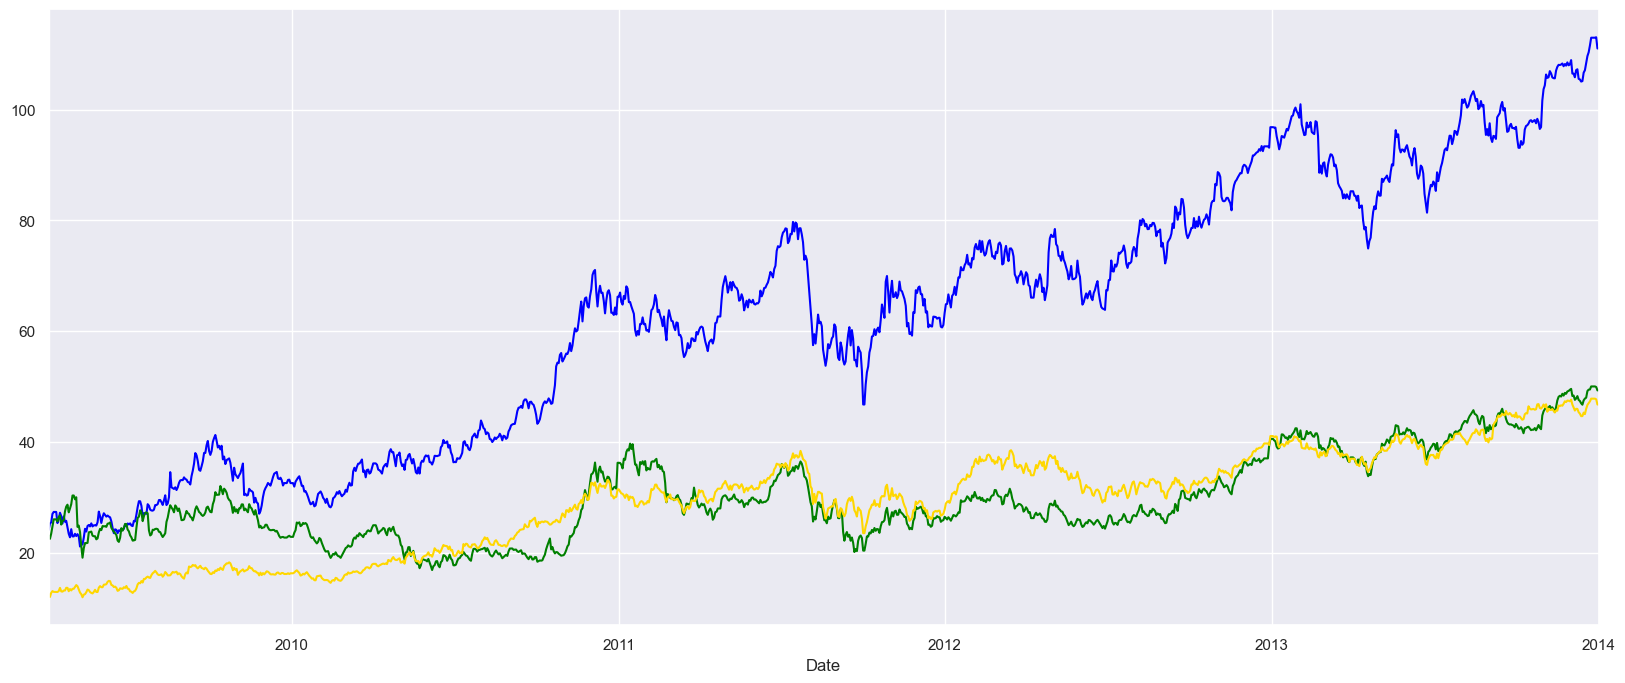

In [8]:
df['vol'][start_date:end_date].plot(figsize= (20,8), color = "blue")
df['por'][start_date:end_date].plot(color = "green")
df['bmw'][start_date:end_date].plot(color = "gold")
plt.show()

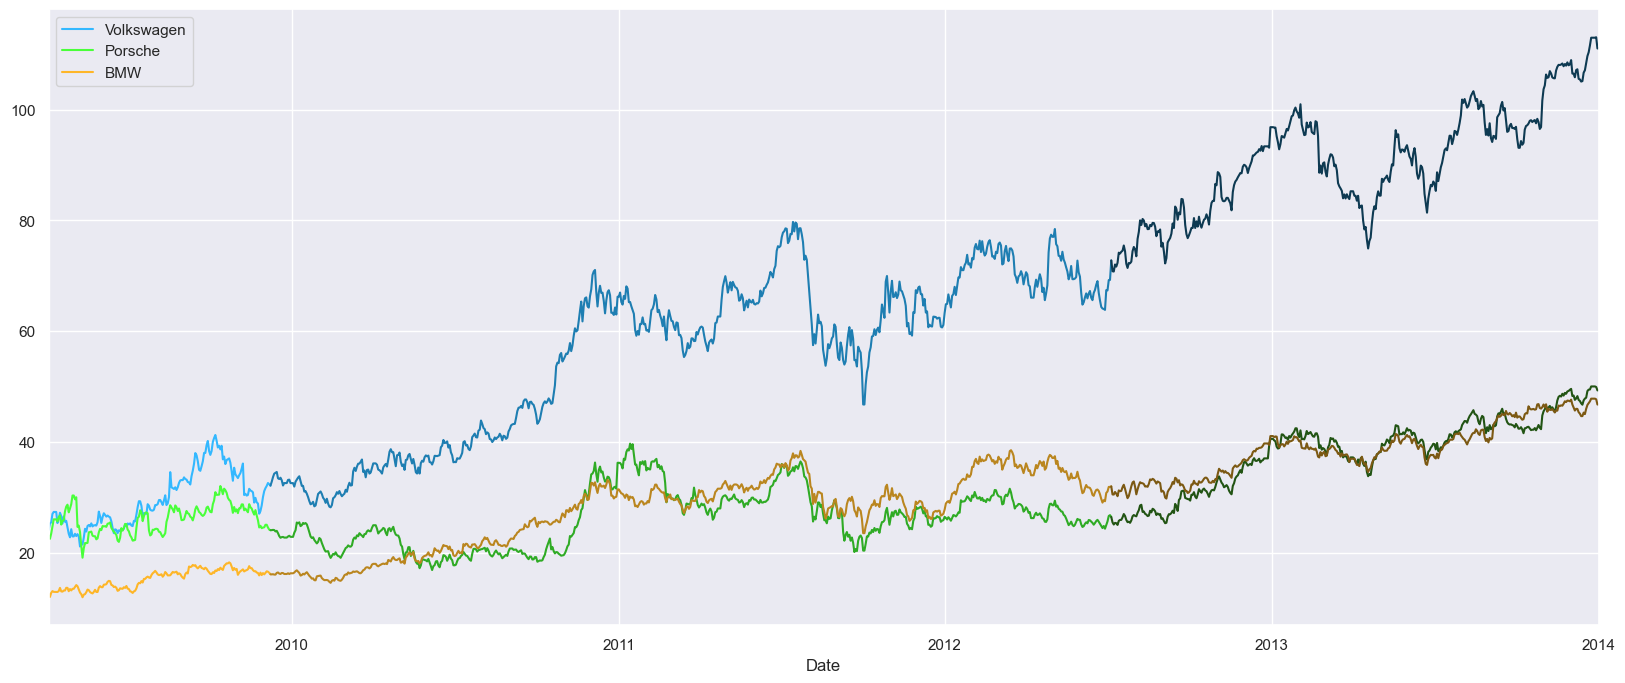

In [9]:
df['vol'][start_date:ann_1].plot(figsize= (20,8), color = "#33B8FF")
df['por'][start_date:ann_1].plot(color = "#49FF3A")
df['bmw'][start_date:ann_1].plot(color = "#FEB628")

df['vol'][ann_1:ann_2].plot(color = "#1E7EB2")
df['por'][ann_1:ann_2].plot(color = "#2FAB25")
df['bmw'][ann_1:ann_2].plot(color = "#BA861F")

df['vol'][ann_2:end_date].plot(color = "#0E3A52")
df['por'][ann_2:end_date].plot(color = "#225414")
df['bmw'][ann_2:end_date].plot(color = "#7C5913")

plt.legend(['Volkswagen','Porsche','BMW'])

plt.show()


## Correlation

In [10]:
print('Correlation among manufacturers from ' + str(start_date) + ' to ' + str(end_date)+ '\n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][start_date:end_date].corr(df['por'][start_date:end_date])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][start_date:end_date].corr(df['bmw'][start_date:end_date])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][start_date:end_date].corr(df['bmw'][start_date:end_date])))

Correlation among manufacturers from 2009-04-05 to 2014-01-01

Volkswagen and Porsche correlation: 	0.8359541710052173
Volkswagen and BMW correlation: 	0.9799378254380441
Porsche and BMW correlation: 		0.8052154747616819


VW moves in a similar way to the market benchmark

In [11]:
print('Correlation among manufacturers from ' + str(start_date) + ' to ' + str(ann_1)+ '\n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][start_date:ann_1].corr(df['por'][start_date:ann_1])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][start_date:ann_1].corr(df['bmw'][start_date:ann_1])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][start_date:ann_1].corr(df['bmw'][start_date:ann_1])))

Correlation among manufacturers from 2009-04-05 to 2009-12-09

Volkswagen and Porsche correlation: 	0.6633584194954264
Volkswagen and BMW correlation: 	0.8427607660833222
Porsche and BMW correlation: 		0.6095039775375197


The stock prices for these brands weren't too similar before the start of the buyout

In [12]:
print('Correlation among manufacturers from ' + str(ann_1) + ' to ' + str(ann_2)+ '\n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][ann_1:ann_2].corr(df['por'][ann_1:ann_2])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][ann_1:ann_2].corr(df['bmw'][ann_1:ann_2])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][ann_1:ann_2].corr(df['bmw'][ann_1:ann_2])))

Correlation among manufacturers from 2009-12-09 to 2012-07-05

Volkswagen and Porsche correlation: 	0.7428267367015703
Volkswagen and BMW correlation: 	0.9795942988249543
Porsche and BMW correlation: 		0.7042723023159325


In [13]:
print('Correlation among manufacturers from ' + str(ann_2) + ' to ' + str(end_date)+ '\n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][ann_2:end_date].corr(df['por'][ann_2:end_date])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][ann_2:end_date].corr(df['bmw'][ann_2:end_date])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][ann_2:end_date].corr(df['bmw'][ann_2:end_date])))

Correlation among manufacturers from 2012-07-05 to 2014-01-01

Volkswagen and Porsche correlation: 	0.9405236884530109
Volkswagen and BMW correlation: 	0.9284447646300531
Porsche and BMW correlation: 		0.9494111907921672


In [14]:
print('Correlation among manufacturers from ' + str(end_date) + ' to ' + str(df.index[-1])+ '\n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][end_date:].corr(df['por'][end_date:])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][end_date:].corr(df['bmw'][end_date:])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][end_date:].corr(df['bmw'][end_date:])))

Correlation among manufacturers from 2014-01-01 to 2026-02-19 00:00:00

Volkswagen and Porsche correlation: 	0.8593555429210278
Volkswagen and BMW correlation: 	0.3461573147583561
Porsche and BMW correlation: 		0.0999297685012733


# Analyzing the Dieselgate case

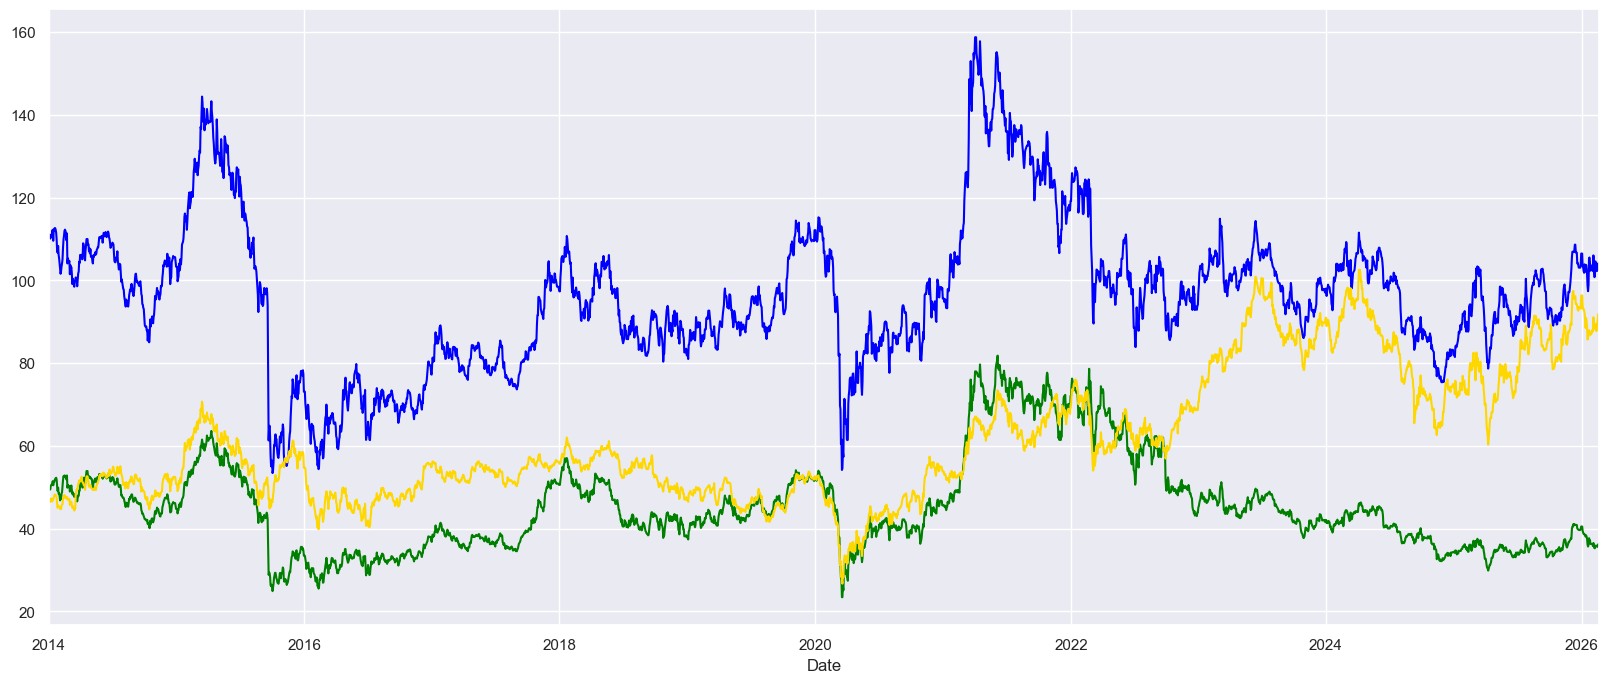

In [15]:
df['vol'][end_date:].plot(figsize= (20,8), color = "blue")
df['por'][end_date:].plot(color = "green")
df['bmw'][end_date:].plot(color = "gold")
plt.show()

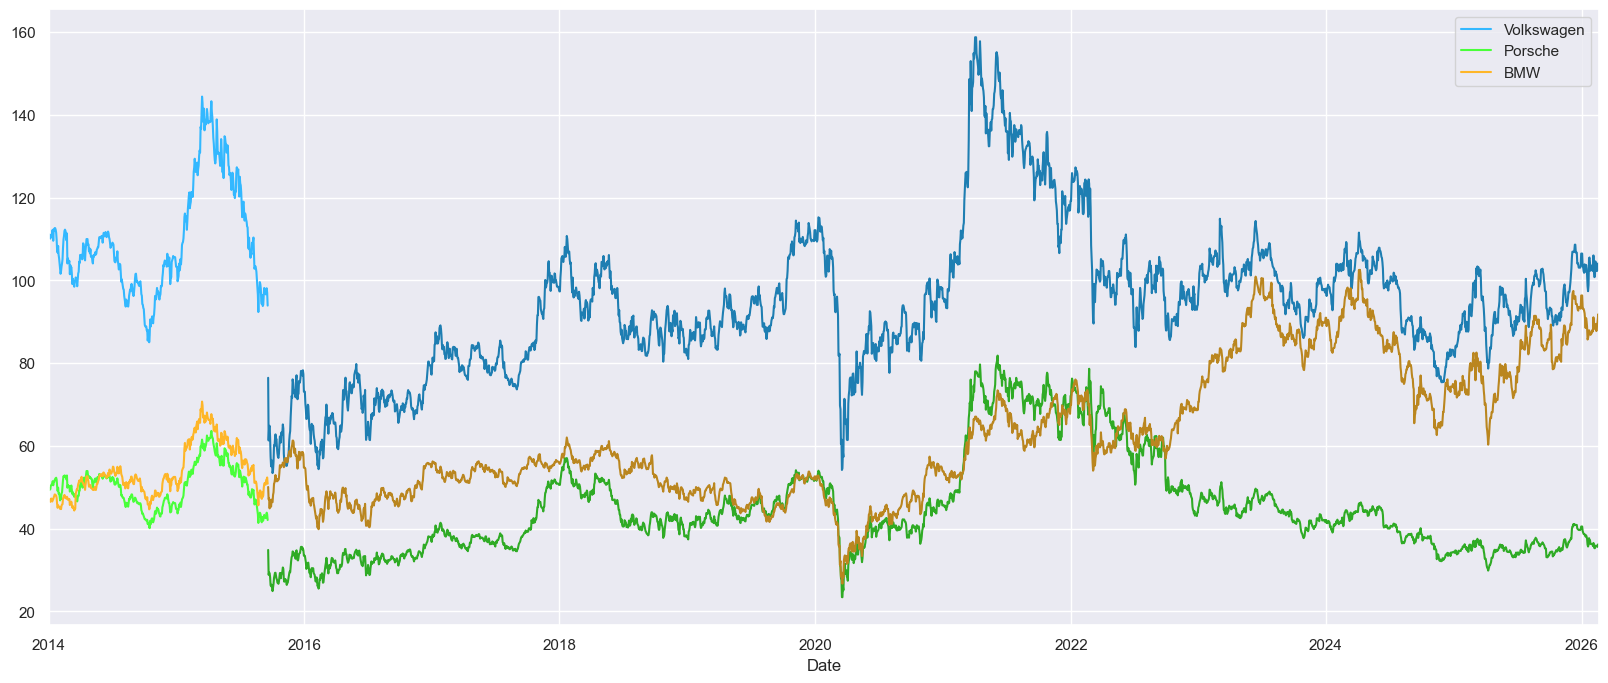

In [16]:
df['vol'][end_date:d_gate].plot(figsize= (20,8), color = "#33B8FF")
df['por'][end_date:d_gate].plot(color = "#49FF3A")
df['bmw'][end_date:d_gate].plot(color = "#FEB628")

df['vol'][d_gate:].plot(color = "#1E7EB2")
df['por'][d_gate:].plot(color = "#2FAB25")
df['bmw'][d_gate:].plot(color = "#BA861F")

plt.legend(['Volkswagen','Porsche','BMW'])

plt.show()

In [17]:
print('Correlation among manufacturers from ' + str(end_date) + ' to last date \n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][end_date:].corr(df['por'][end_date:])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][end_date:].corr(df['bmw'][end_date:])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][end_date:].corr(df['bmw'][end_date:])))

Correlation among manufacturers from 2014-01-01 to last date 

Volkswagen and Porsche correlation: 	0.8593555429210278
Volkswagen and BMW correlation: 	0.3461573147583561
Porsche and BMW correlation: 		0.0999297685012733


In [18]:
print('Correlation among manufacturers from ' + str(end_date) + ' to ' + str(d_gate)+ '\n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][end_date:d_gate].corr(df['por'][end_date:d_gate])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][end_date:d_gate].corr(df['bmw'][end_date:d_gate])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][end_date:d_gate].corr(df['bmw'][end_date:d_gate])))

Correlation among manufacturers from 2014-01-01 to 2015-09-20

Volkswagen and Porsche correlation: 	0.9421375932861749
Volkswagen and BMW correlation: 	0.8912208096818482
Porsche and BMW correlation: 		0.8045871457440836


In [19]:
print('Correlation among manufacturers from ' + str(d_gate) + ' to last date \n')
print('Volkswagen and Porsche correlation: \t'+ str(df['vol'][d_gate:].corr(df['por'][d_gate:])))
print('Volkswagen and BMW correlation: \t'+ str(df['vol'][d_gate:].corr(df['bmw'][d_gate:])))
print('Porsche and BMW correlation: \t\t'+ str(df['por'][d_gate:].corr(df['bmw'][d_gate:])))

Correlation among manufacturers from 2015-09-20 to last date 

Volkswagen and Porsche correlation: 	0.8631972104122047
Volkswagen and BMW correlation: 	0.4238508017985459
Porsche and BMW correlation: 		0.12220191104330289


## Best Fitting Models

### For Volkswagen

In [20]:
mod_pr_pre_vol = auto_arima(df.vol[start_date:ann_1], exogenous = df[['por','bmw']][start_date:ann_1],
                            m = 5, max_p = 5, max_q = 5)
mod_pr_btn_vol = auto_arima(df.vol[ann_1:ann_2], exogenous = df[['por','bmw']][ann_1:ann_2],
                            m = 5, max_p = 5, max_q = 5)
mod_pr_post_vol = auto_arima(df.vol[ann_2:end_date], exogenous = df[['por','bmw']][ann_2:end_date],
                            m = 5, max_p = 5, max_q = 5)

In [21]:
mod_pr_pre_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  178
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -260.869
Date:                Thu, 19 Feb 2026   AIC                            523.737
Time:                        14:54:19   BIC                            526.913
Sample:                    04-06-2009   HQIC                           525.025
                         - 12-09-2009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.1160      0.062     17.983      0.000       0.994       1.238
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):               232.52
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               2.10   Skew:                            -0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
mod_pr_btn_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  672
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1174.057
Date:                Thu, 19 Feb 2026   AIC                           2352.113
Time:                        14:54:19   BIC                           2361.131
Sample:                    12-09-2009   HQIC                          2355.606
                         - 07-05-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0899      0.034      2.645      0.008       0.023       0.156
sigma2         1.9377      0.078     24.998      0.000       1.786       2.090
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                85.28
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               5.54   Skew:                             0.07
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
mod_pr_post_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  390
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -665.024
Date:                Thu, 19 Feb 2026   AIC                           1334.048
Time:                        14:54:19   BIC                           1341.975
Sample:                    07-05-2012   HQIC                          1337.191
                         - 01-01-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0879      0.047      1.861      0.063      -0.005       0.180
sigma2         1.7883      0.093     19.175      0.000       1.605       1.971
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                61.79
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                            -0.15
Prob(H) (two-sided):                  0.56   Kurtosis:                         4.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The price of Porsche today will be a more accurate estimator than the price of VW yesterday. This shift occurs because the two automobile manufacturers are now a single entity.  
New information seems to have a higher impact on trends compared to past patterns.

### Dieselgate scandal

In [24]:
mod_pr_dgate_vol = auto_arima(df.vol[end_date:d_gate], exogenous = df[['por','bmw']][end_date:d_gate],
                            m = 5, max_p = 5, max_q = 5)
mod_pr_dgate2_vol = auto_arima(df.vol[d_gate:], exogenous = df[['por','bmw']][d_gate:],
                            m = 5, max_p = 5, max_q = 5)

In [25]:
mod_pr_dgate_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  448
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -887.498
Date:                Thu, 19 Feb 2026   AIC                           1776.996
Time:                        14:57:47   BIC                           1781.098
Sample:                    01-01-2014   HQIC                          1778.613
                         - 09-18-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         3.1050      0.154     20.122      0.000       2.803       3.407
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):                51.96
Prob(Q):                              0.44   Prob(JB):                         0.00
Heteroskedasticity (H):               3.01   Skew:                             0.16
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [26]:
mod_pr_dgate2_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 2719
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 5)   Log Likelihood               -5589.007
Date:                           Thu, 19 Feb 2026   AIC                          11188.014
Time:                                   14:57:47   BIC                          11217.553
Sample:                               09-21-2015   HQIC                         11198.693
                                    - 02-19-2026                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7298      0.086     -8.444      0.000      -0.899      -0.560
ma.L1          0.7828      0.080      9.814      0.000       0.626       0.939
ar.S.L5       -0.7418      0.167     -4.454      0.000      -1.068      -0.415
ma.S.L5        0.7115      0.175      4.072      0.000       0.369       1.054
sigma2         3.5776      0.049     73.124      0.000       3.482       3.673
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):              4730.71
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                             0.09
Prob(H) (two-sided):                  0.39   Kurtosis:                         9.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### For Porsche

In [27]:
mod_pr_pre_por = auto_arima(df.por[start_date:ann_1], exogenous = df[['vol','bmw']][start_date:ann_1],
                            m = 5, max_p = 5, max_q = 5)
mod_pr_btn_por = auto_arima(df.por[ann_1:ann_2], exogenous = df[['vol','bmw']][ann_1:ann_2],
                            m = 5, max_p = 5, max_q = 5)
mod_pr_post_por = auto_arima(df.por[ann_2:end_date], exogenous = df[['vol','bmw']][ann_2:end_date],
                             m = 5, max_p = 5, max_q = 5)

In [28]:
mod_pr_pre_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  178
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -236.237
Date:                Thu, 19 Feb 2026   AIC                            474.473
Time:                        14:58:07   BIC                            477.649
Sample:                    04-06-2009   HQIC                           475.761
                         - 12-09-2009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.8449      0.044     19.004      0.000       0.758       0.932
===================================================================================
Ljung-Box (L1) (Q):                   3.50   Jarque-Bera (JB):               319.80
Prob(Q):                              0.06   Prob(JB):                         0.00
Heteroskedasticity (H):               0.38   Skew:                            -1.13
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
mod_pr_btn_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  672
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -750.145
Date:                Thu, 19 Feb 2026   AIC                           1504.289
Time:                        14:58:07   BIC                           1513.307
Sample:                    12-09-2009   HQIC                          1507.782
                         - 07-05-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1096      0.032      3.457      0.001       0.047       0.172
sigma2         0.5477      0.017     32.054      0.000       0.514       0.581
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               483.16
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               2.15   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [30]:
mod_pr_post_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  390
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -374.701
Date:                Thu, 19 Feb 2026   AIC                            753.402
Time:                        14:58:07   BIC                            761.329
Sample:                    07-05-2012   HQIC                           756.545
                         - 01-01-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0588      0.032      1.824      0.068      -0.004       0.122
sigma2         0.4020      0.023     17.659      0.000       0.357       0.447
===================================================================================
Ljung-Box (L1) (Q):                   1.32   Jarque-Bera (JB):                25.52
Prob(Q):                              0.25   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                             0.14
Prob(H) (two-sided):                  0.97   Kurtosis:                         4.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

We see that these trends are affected more by current events rather than pre-existing patterns.  
We just examined two cases where we see major trend changes ocurring after new information is introduced. However, we were using the same type of non stationary prices for both.

### Dieselgate scandal

In [31]:
mod_pr_dgate_por = auto_arima(df.por[end_date:d_gate], exogenous = df[['por','bmw']][end_date:d_gate],
                            m = 5, max_p = 5, max_q = 5)
mod_pr_dgate2_por = auto_arima(df.por[d_gate:], exogenous = df[['por','bmw']][d_gate:],
                            m = 5, max_p = 5, max_q = 5)

In [32]:
mod_pr_dgate_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  448
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -514.494
Date:                Thu, 19 Feb 2026   AIC                           1034.989
Time:                        15:02:45   BIC                           1047.296
Sample:                    01-01-2014   HQIC                          1039.841
                         - 09-18-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8449      0.081    -10.468      0.000      -1.003      -0.687
ma.L1          0.9121      0.063     14.583      0.000       0.790       1.035
sigma2         0.5850      0.034     17.377      0.000       0.519       0.651
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                10.86
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               1.76   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
mod_pr_dgate2_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                 2719
Model:             SARIMAX(1, 1, 1)x(2, 0, [1, 2], 5)   Log Likelihood               -3708.558
Date:                                Thu, 19 Feb 2026   AIC                           7431.116
Time:                                        15:02:45   BIC                           7472.470
Sample:                                    09-21-2015   HQIC                          7446.066
                                         - 02-19-2026                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6226      0.122     -5.110      0.000      -0.861      -0.384
ma.L1          0.6700      0.115      5.811      0.000       0.444       0.896
ar.S.L5       -1.6454      0.047    -35.365      0.000      -1.737      -1.554
ar.S.L10      -0.8837      0.040    -22.078      0.000      -0.962      -0.805
ma.S.L5        1.6162      0.047     34.317      0.000       1.524       1.709
ma.S.L10       0.8761      0.040     22.027      0.000       0.798       0.954
sigma2         0.8979      0.011     83.848      0.000       0.877       0.919
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):             11349.19
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                             0.19
Prob(H) (two-sided):                  0.02   Kurtosis:                        13.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Best Fitting Models for returns

### Volkswagen

In [34]:
mod_ret_pre_vol = auto_arima(df.ret_vol[start_date:ann_1], exogenous = df[['por','bmw']][start_date:ann_1],
                            m = 5, max_p = 5, max_q = 5)
mod_ret_btn_vol = auto_arima(df.ret_vol[ann_1:ann_2], exogenous = df[['por','bmw']][ann_1:ann_2],
                            m = 5, max_p = 5, max_q = 5)
mod_ret_post_vol = auto_arima(df.ret_vol[ann_2:end_date], exogenous = df[['por','bmw']][ann_2:end_date],
                            m = 5, max_p = 5, max_q = 5)

In [35]:
mod_ret_pre_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  178
Model:                        SARIMAX   Log Likelihood                -476.494
Date:                Thu, 19 Feb 2026   AIC                            954.989
Time:                        15:02:54   BIC                            958.170
Sample:                    04-06-2009   HQIC                           956.279
                         - 12-09-2009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        12.3789      0.835     14.821      0.000      10.742      14.016
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                70.23
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                            -0.26
Prob(H) (two-sided):                  0.93   Kurtosis:                         6.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [36]:
mod_ret_btn_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  672
Model:               SARIMAX(0, 0, 1)   Log Likelihood               -1558.899
Date:                Thu, 19 Feb 2026   AIC                           3121.799
Time:                        15:02:54   BIC                           3130.819
Sample:                    12-09-2009   HQIC                          3125.292
                         - 07-05-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1304      0.029      4.473      0.000       0.073       0.187
sigma2         6.0598      0.249     24.296      0.000       5.571       6.549
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                67.50
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.94   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
mod_ret_post_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  390
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -729.133
Date:                Thu, 19 Feb 2026   AIC                           1464.266
Time:                        15:02:54   BIC                           1476.165
Sample:                    07-05-2012   HQIC                          1468.983
                         - 01-01-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1533      0.079      1.932      0.053      -0.002       0.309
ar.L1          0.1030      0.045      2.300      0.021       0.015       0.191
sigma2         2.4626      0.136     18.166      0.000       2.197       2.728
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                33.22
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.55   Skew:                             0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Dieselgate scandal

In [38]:
mod_ret_dgate_vol = auto_arima(df.ret_vol[end_date:d_gate], exogenous = df[['por','bmw']][end_date:d_gate],
                            m = 5, max_p = 5, max_q = 5)
mod_ret_dgate2_vol = auto_arima(df.ret_vol[d_gate:], exogenous = df[['por','bmw']][d_gate:],
                            m = 5, max_p = 5, max_q = 5)

In [39]:
mod_ret_dgate_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  448
Model:                        SARIMAX   Log Likelihood                -839.004
Date:                Thu, 19 Feb 2026   AIC                           1680.008
Time:                        15:05:45   BIC                           1684.112
Sample:                    01-01-2014   HQIC                          1681.626
                         - 09-18-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         2.4786      0.133     18.632      0.000       2.218       2.739
===================================================================================
Ljung-Box (L1) (Q):                   0.62   Jarque-Bera (JB):                25.16
Prob(Q):                              0.43   Prob(JB):                         0.00
Heteroskedasticity (H):               2.24   Skew:                             0.16
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [40]:
mod_ret_dgate2_vol.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2719
Model:               SARIMAX(3, 0, 4)   Log Likelihood               -5907.383
Date:                Thu, 19 Feb 2026   AIC                          11830.766
Time:                        15:05:45   BIC                          11878.030
Sample:                    09-21-2015   HQIC                         11847.852
                         - 02-19-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1689      0.108      1.567      0.117      -0.042       0.380
ar.L2         -0.0828      0.089     -0.927      0.354      -0.258       0.092
ar.L3         -0.7375      0.089     -8.328      0.000      -0.911      -0.564
ma.L1         -0.0460      0.109     -0.424      0.672      -0.259       0.167
ma.L2          0.0679      0.073      0.925      0.355      -0.076       0.212
ma.L3          0.8048      0.077     10.490      0.000       0.654       0.955
ma.L4          0.0695      0.023      2.973      0.003       0.024       0.115
sigma2         4.5053      0.058     77.971      0.000       4.392       4.619
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):             10335.25
Prob(Q):                              0.71   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Porsche

In [41]:
mod_ret_pre_por = auto_arima(df.ret_por[start_date:ann_1], exogenous = df[['vol','bmw']][start_date:ann_1],
                            m = 5, max_p = 5, max_q = 5)
mod_ret_btn_por = auto_arima(df.ret_por[ann_1:ann_2], exogenous = df[['vol','bmw']][ann_1:ann_2],
                            m = 5, max_p = 5, max_q = 5)
mod_ret_post_por = auto_arima(df.ret_por[ann_2:end_date], exogenous = df[['vol','bmw']][ann_2:end_date],
                             m = 5, max_p = 5, max_q = 5)

In [42]:
mod_ret_pre_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  178
Model:             SARIMAX(1, 0, 0)x(0, 0, [1], 5)   Log Likelihood                -475.191
Date:                             Thu, 19 Feb 2026   AIC                            956.382
Time:                                     15:06:04   BIC                            965.927
Sample:                                 04-06-2009   HQIC                           960.252
                                      - 12-09-2009                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1759      0.064      2.735      0.006       0.050       0.302
ma.S.L5       -0.1792      0.062     -2.909      0.004      -0.300      -0.058
sigma2        12.1855      0.816     14.942      0.000      10.587      13.784
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               116.07
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.35   Skew:                            -0.73
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [43]:
mod_ret_btn_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  672
Model:               SARIMAX(0, 0, 1)   Log Likelihood               -1656.533
Date:                Thu, 19 Feb 2026   AIC                           3317.065
Time:                        15:06:04   BIC                           3326.086
Sample:                    12-09-2009   HQIC                          3320.559
                         - 07-05-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1878      0.027      6.920      0.000       0.135       0.241
sigma2         8.1028      0.298     27.210      0.000       7.519       8.686
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               193.77
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.56   Skew:                             0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:
mod_ret_post_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  390
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 5)   Log Likelihood                -773.645
Date:                           Thu, 19 Feb 2026   AIC                           1555.289
Time:                                   15:06:04   BIC                           1571.154
Sample:                               07-05-2012   HQIC                          1561.578
                                    - 01-01-2014                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2207      0.092      2.387      0.017       0.039       0.402
ma.L1          0.1003      0.052      1.936      0.053      -0.001       0.202
ma.S.L5       -0.0773      0.046     -1.684      0.092      -0.167       0.013
sigma2         3.0938      0.176     17.598      0.000       2.749       3.438
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.90
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.49   Skew:                             0.35
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Dieselgate scandal

In [45]:
mod_ret_dgate_por = auto_arima(df.ret_por[end_date:d_gate], exogenous = df[['por','bmw']][end_date:d_gate],
                            m = 5, max_p = 5, max_q = 5)
mod_ret_dgate2_por = auto_arima(df.ret_por[d_gate:], exogenous = df[['por','bmw']][d_gate:],
                            m = 5, max_p = 5, max_q = 5)

In [46]:
mod_ret_dgate_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  448
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -827.966
Date:                Thu, 19 Feb 2026   AIC                           1661.933
Time:                        15:06:27   BIC                           1674.247
Sample:                    01-01-2014   HQIC                          1666.787
                         - 09-18-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8656      0.079    -10.985      0.000      -1.020      -0.711
ma.L1          0.9248      0.061     15.172      0.000       0.805       1.044
sigma2         2.3589      0.141     16.780      0.000       2.083       2.634
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 7.61
Prob(Q):                              0.84   Prob(JB):                         0.02
Heteroskedasticity (H):               1.62   Skew:                             0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [47]:
mod_ret_dgate2_por.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2719
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -5861.352
Date:                Thu, 19 Feb 2026   AIC                          11726.703
Time:                        15:06:27   BIC                          11738.520
Sample:                    09-21-2015   HQIC                         11730.975
                         - 02-19-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1185      0.011     10.543      0.000       0.096       0.141
sigma2         4.3646      0.049     89.318      0.000       4.269       4.460
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):             11136.70
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               0.55   Skew:                            -0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Predictions for the Future

### For Porsche

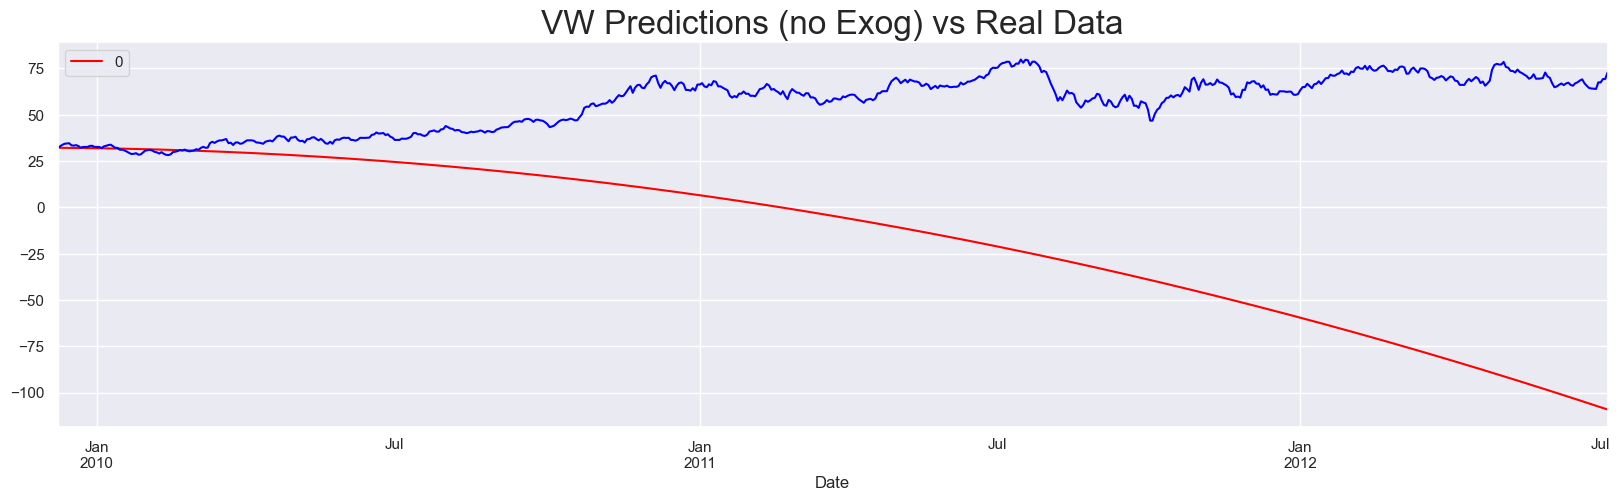

In [48]:
# We're going to use the auto.arima method again, but we'll loosen up the restrictions a bit to ensure a better fit.
# For the time being, we won't include either of the other time series as an exogenous variable

model_auto_pred_pr = auto_arima(df.vol[start_date:ann_1], m = 5, max_p = 5, max_q = 5, max_P = 5, max_Q = 5, trend = "ct")

df_auto_pred_pr = pd.DataFrame(model_auto_pred_pr.predict(n_periods = len(df[ann_1:ann_2])), index = df[ann_1:ann_2].index)
df_auto_pred_pr[ann_1:ann_2].plot(figsize = (20,5), color = "red")

df.vol[ann_1:ann_2].plot(color = "blue")
plt.title("VW Predictions (no Exog) vs Real Data", size = 24)
plt.show()

At first glance, the predictions seem very good over the first 3 or 4 months, but then start to die off faster and faster. 

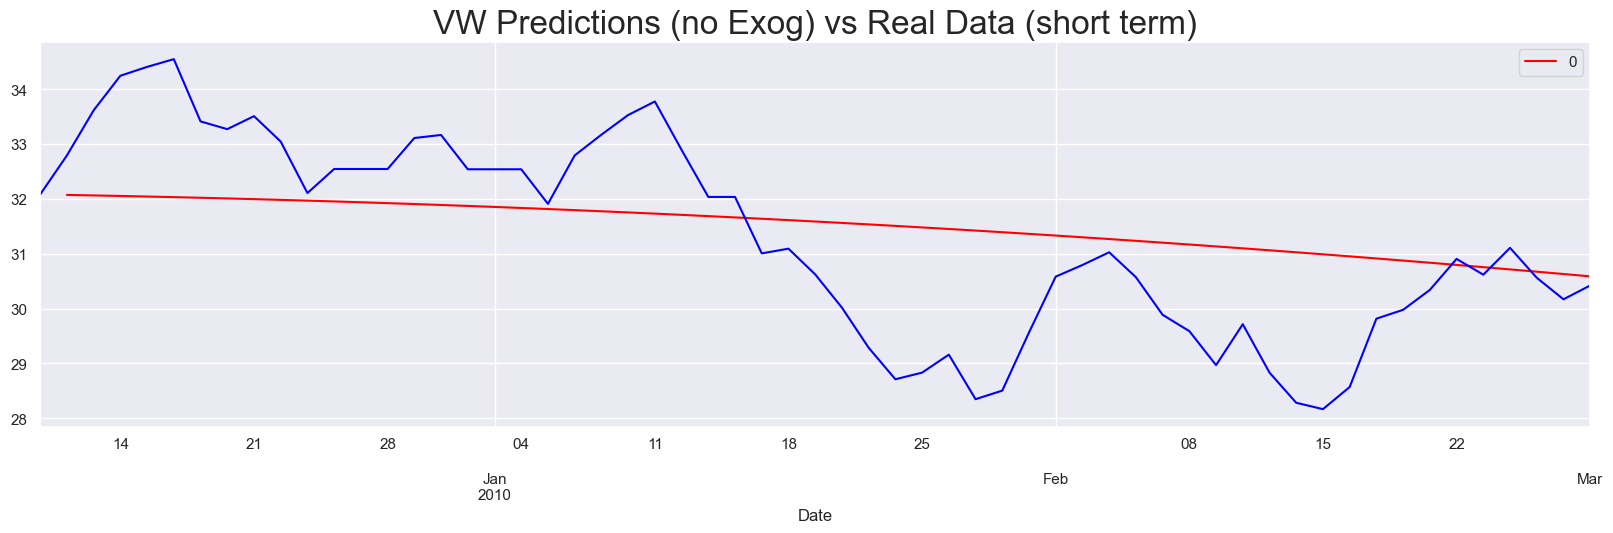

In [49]:
df_auto_pred_pr[ann_1:'2010-03-01'].plot(figsize = (20,5), color = "red")
df.vol[ann_1:'2010-03-01'].plot(color = "blue")
plt.title("VW Predictions (no Exog) vs Real Data (short term)", size = 24)
plt.show()

We see that the predictions weren't really close day by day, but captured the general trend over the entire period
This means the predictions would only be useful if we were trying to ballpark the quarterly performance of prices

### For Volkswagen

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[5] intercept   : AIC=535.664, Time=1.22 sec
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=936.602, Time=0.16 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=531.721, Time=0.71 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=720.450, Time=0.82 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=936.602, Time=0.16 sec
 ARIMA(1,0,0)(0,0,0)[5] intercept   : AIC=529.805, Time=0.09 sec
 ARIMA(1,0,0)(0,0,1)[5] intercept   : AIC=531.721, Time=0.70 sec
 ARIMA(1,0,0)(1,0,1)[5] intercept   : AIC=533.662, Time=1.57 sec
 ARIMA(2,0,0)(0,0,0)[5] intercept   : AIC=531.712, Time=0.24 sec
 ARIMA(1,0,1)(0,0,0)[5] intercept   : AIC=531.693, Time=0.18 sec
 ARIMA(0,0,1)(0,0,0)[5] intercept   : AIC=770.720, Time=0.27 sec
 ARIMA(2,0,1)(0,0,0)[5] intercept   : AIC=533.591, Time=0.69 sec
 ARIMA(1,0,0)(0,0,0)[5]             : AIC=529.805, Time=0.10 sec

Best model:  ARIMA(1,0,0)(0,0,0)[5] intercept
Total fit time: 6.966 seconds


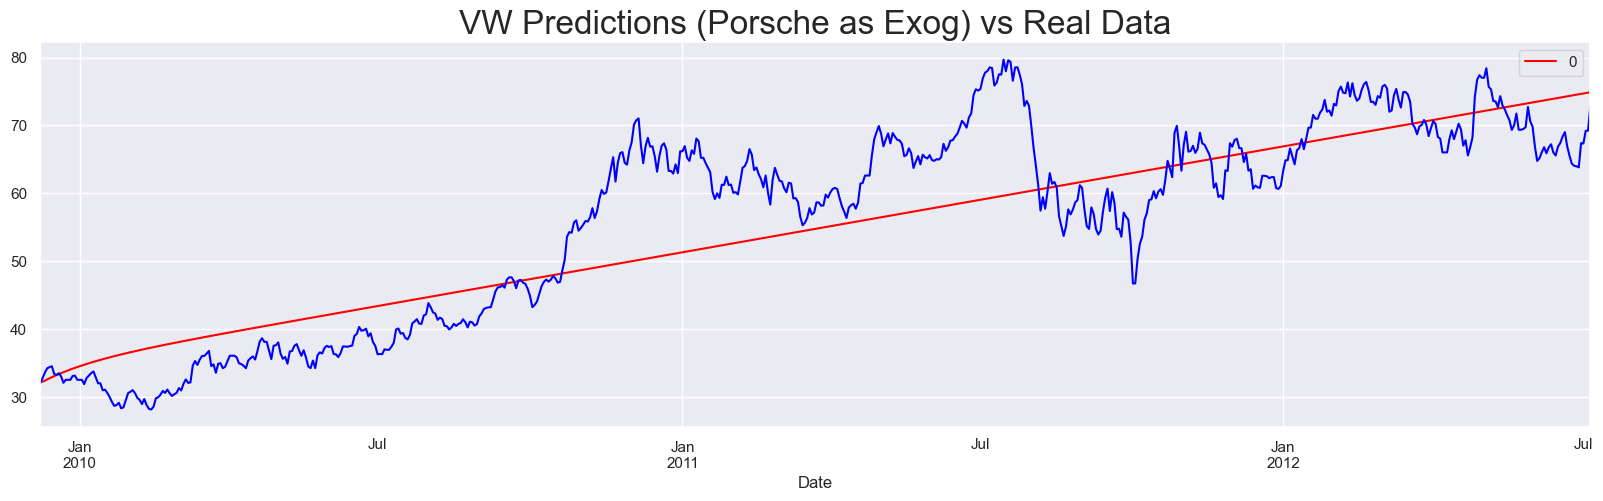

In [50]:
model_auto_pred_pr = auto_arima(df.vol[start_date:ann_1], exogenous = df[['por']][start_date:ann_1],
                          m = 5, start_p=1, start_q=1, max_p = 15, max_q = 15, max_P = 15, max_Q = 15, d=0, trend = "ct", stepwise=True,
                          trace=True, information_criterion='oob')

df_auto_pred_pr = pd.DataFrame(model_auto_pred_pr.predict(n_periods = len(df[ann_1:ann_2]),exogenous = df[['por']][ann_1:ann_2]),
                               index = df[ann_1:ann_2].index)
df_auto_pred_pr[ann_1:ann_2].plot(figsize = (20,5), color = "red")

df.vol[ann_1:ann_2].plot(color = "blue")
plt.title("VW Predictions (Porsche as Exog) vs Real Data", size = 24)
plt.show()

A trend that doesn't simply die off exponentially
Also in this we see that the predictions weren't really close day by day, but captured the general trend over the entire period
This means the predictions would only be useful if we were trying to ballpark the quarterly performance of prices

In [51]:
model_auto_pred_pr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  178
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -260.903
Date:                Thu, 19 Feb 2026   AIC                            529.805
Time:                        15:06:39   BIC                            542.532
Sample:                    04-06-2009   HQIC                           534.966
                         - 12-09-2009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.1908      0.625      1.905      0.057      -0.034       2.416
drift          0.0028      0.002      1.237      0.216      -0.002       0.007
ar.L1          0.9529      0.024     38.999      0.000       0.905       1.001
sigma2         1.0889      0.066     16.421      0.000       0.959       1.219
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):               221.53
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.09   Skew:                            -0.56
Prob(H) (two-sided):                  0.01   Kurtosis:                         8.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[5] intercept   : AIC=541.550, Time=0.69 sec
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=936.602, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=531.721, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=720.450, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=936.602, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[5] intercept   : AIC=529.805, Time=0.06 sec
 ARIMA(1,0,0)(0,0,1)[5] intercept   : AIC=531.721, Time=0.49 sec
 ARIMA(1,0,0)(1,0,1)[5] intercept   : AIC=533.662, Time=0.57 sec
 ARIMA(2,0,0)(0,0,0)[5] intercept   : AIC=531.712, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[5] intercept   : AIC=531.693, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[5] intercept   : AIC=770.720, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[5] intercept   : AIC=533.591, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[5]             : AIC=529.805, Time=0.06 sec

Best model:  ARIMA(1,0,0)(0,0,0)[5]          
Total fit time: 3.019 seconds


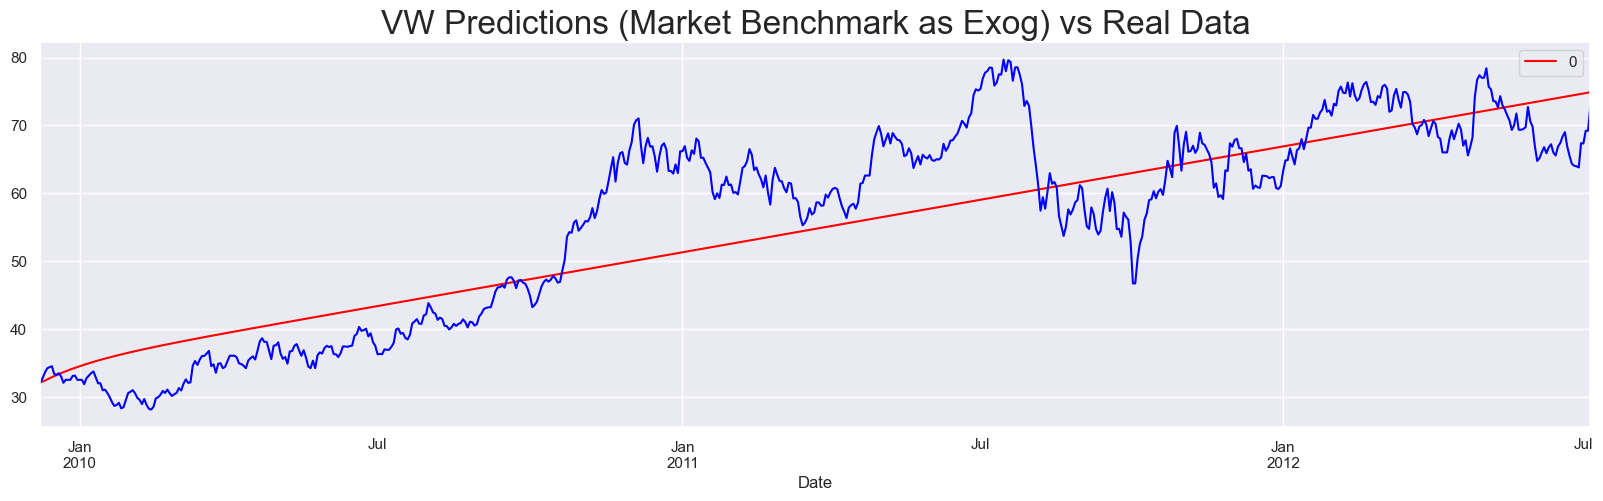

In [52]:
model_auto_pred_pr = auto_arima(df.vol[start_date:ann_1], exogenous = df[['bmw']][start_date:ann_1],
                          m = 5, max_p = 5, max_q = 5, max_P = 5, max_Q = 5, trend = "ct", d=0, stepwise=True,
                          trace=True)

df_auto_pred_pr = pd.DataFrame(model_auto_pred_pr.predict(n_periods = len(df[ann_1:ann_2]), exogenous = df[['bmw']][ann_1:ann_2]),
                               index = df[ann_1:ann_2].index)
df_auto_pred_pr[ann_1:ann_2].plot(figsize = (20,5), color = "red")

df.vol[ann_1:ann_2].plot(color = "blue")
plt.title("VW Predictions (Market Benchmark as Exog) vs Real Data", size = 24)
plt.show()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[5] intercept   : AIC=535.664, Time=0.34 sec
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=936.602, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=531.721, Time=0.23 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=720.450, Time=0.28 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=936.602, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[5] intercept   : AIC=529.805, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[5] intercept   : AIC=531.721, Time=0.22 sec
 ARIMA(1,0,0)(1,0,1)[5] intercept   : AIC=533.662, Time=0.54 sec
 ARIMA(2,0,0)(0,0,0)[5] intercept   : AIC=531.712, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[5] intercept   : AIC=531.693, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[5] intercept   : AIC=770.720, Time=0.17 sec
 ARIMA(2,0,1)(0,0,0)[5] intercept   : AIC=533.591, Time=0.39 sec
 ARIMA(1,0,0)(0,0,0)[5]             : AIC=529.805, Time=0.07 sec

Best model:  ARIMA(1,0,0)(0,0,0)[5] intercept
Total fit time: 2.599 seconds


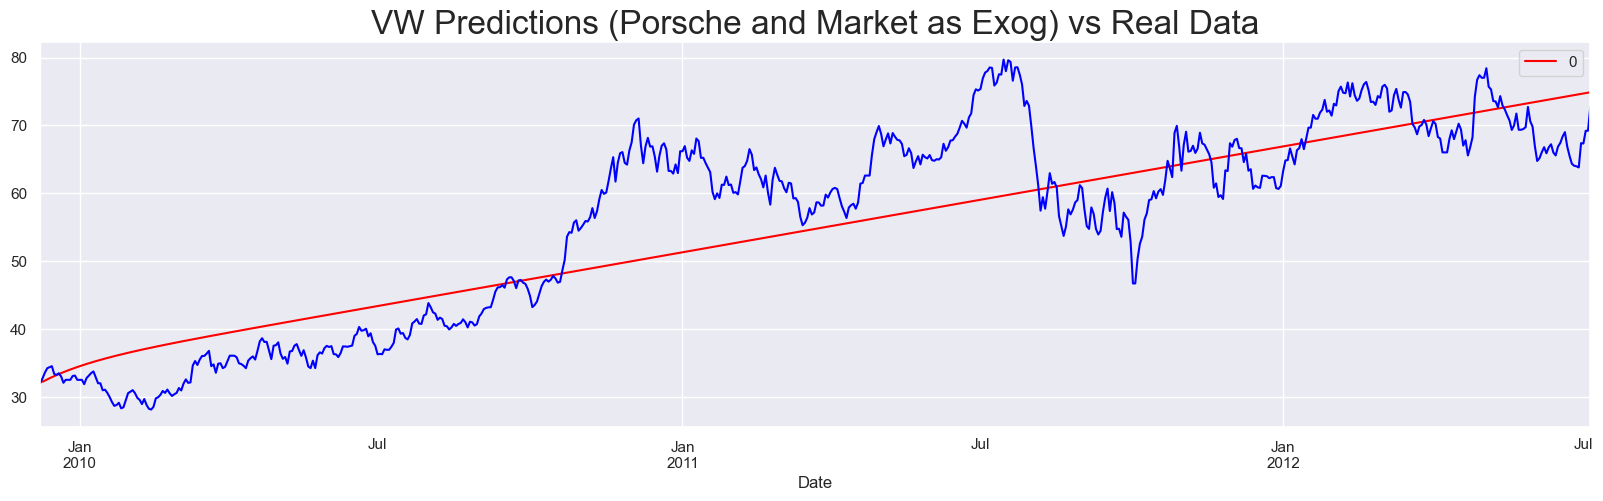

In [53]:
model_auto_pred_pr = auto_arima(df.vol[start_date:ann_1], exogenous = df[['por', 'bmw']][start_date:ann_1],
                          m = 5, start_p=1, start_q=1, max_p = 10, max_q = 10, max_P = 10, max_Q = 10, trend = "ct", d=0, stepwise=True,
                          trace=True)

df_auto_pred_pr = pd.DataFrame(model_auto_pred_pr.predict(n_periods = len(df[ann_1:ann_2]), exogenous = df[['por','bmw']][ann_1:ann_2]),
                               index = df[ann_1:ann_2].index)
df_auto_pred_pr[ann_1:ann_2].plot(figsize = (20,5), color = "red")

df.vol[ann_1:ann_2].plot(color = "blue")
plt.title("VW Predictions (Porsche and Market as Exog) vs Real Data", size = 24)
plt.show()

Therefore, we can confidently say that MAX models are less afected by real life events because the other time series often reflec the changes in the market and help navigate expectations

## Volatility

### Volatility of VW for Each Period

Side Note: We say "surrounding" rather than "after" because rumours and speculations fuel market trade 

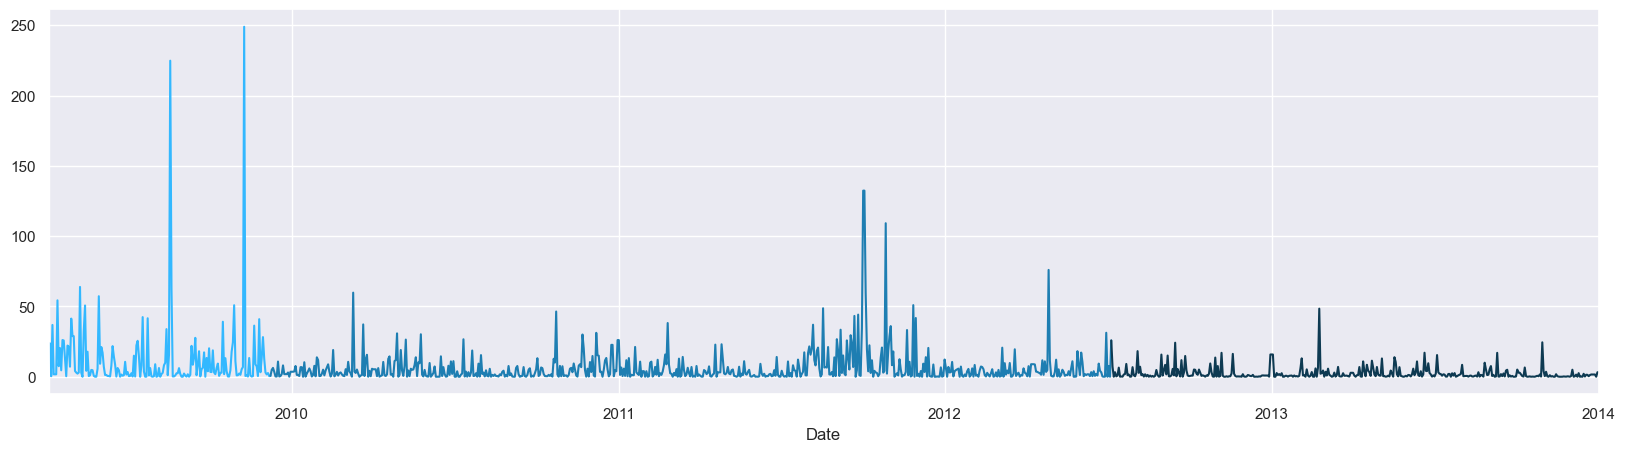

In [54]:
df['sq_vol'][start_date:ann_1].plot(figsize = (20,5), color = "#33B8FF")
df['sq_vol'][ann_1:ann_2].plot(color = "#1E7EB2")
df['sq_vol'][ann_2:end_date].plot(color = "#0E3A52")
plt.show()

We see that Volkswagen has the highest volatility before any of the announcements. This is fascinating because the stock becomes extremely stable following each of the two announcements. While it exhibits instability in the time leading up to each purchase.
Such behavior can most certainly be attributed to the rumors spreading across the market about a deal on the horizon. However, since Porsche had initially tried to purchase VW a few years back, many people weren't certain of how it would all play out.

### Volatility Trends for Each Period

In [55]:
model_garch_pre = arch_model(df.ret_vol[start_date:ann_1], mean = "Constant",  vol = "GARCH", p = 1, q = 1)
results_garch_pre = model_garch_pre.fit(update_freq = 5)

model_garch_btn = arch_model(df.ret_vol[ann_1:ann_2], mean = "Constant",  vol = "GARCH", p = 1, q = 1)
results_garch_btn = model_garch_btn.fit(update_freq = 5)

model_garch_post = arch_model(df.ret_vol[ann_2:end_date], mean = "Constant",  vol = "GARCH", p = 1, q = 1)
results_garch_post = model_garch_post.fit(update_freq = 5)

Iteration:      5,   Func. Count:     31,   Neg. LLF: 475.8121434373225
Iteration:     10,   Func. Count:     56,   Neg. LLF: 475.0388450704105
Optimization terminated successfully    (Exit mode 0)
            Current function value: 475.02457514973815
            Iterations: 14
            Function evaluations: 76
            Gradient evaluations: 14
Iteration:      5,   Func. Count:     38,   Neg. LLF: 1526.7532104112233
Iteration:     10,   Func. Count:     62,   Neg. LLF: 1526.7312794914083
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1526.7312794901636
            Iterations: 10
            Function evaluations: 62
            Gradient evaluations: 10
Iteration:      5,   Func. Count:     34,   Neg. LLF: 724.5622563662951
Optimization terminated successfully    (Exit mode 0)
            Current function value: 724.5579022171271
            Iterations: 7
            Function evaluations: 44
            Gradient evaluations: 7


In [56]:
results_garch_pre.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                ret_vol   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -475.025
Distribution:                  Normal   AIC:                           958.049
Method:            Maximum Likelihood   BIC:                           970.776
                                        No. Observations:                  178
Date:                Thu, Feb 19 2026   Df Residuals:                      177
Time:                        15:25:37   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1568      0.267      0.588      0.556 [ -0.366,  0.679]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         10.6151      4.213      2.520  1.175e-02    [  2.358, 18.872]
alpha[1]       0.1550  9.229e-02      1.680  9.304e-02 [-2.587e-02,  0.336]
beta[1]    2.9013e-13      0.347  8.353e-13      1.000    [ -0.681,  0.681]
===========================================================================

Covariance estimator: robust
"""

For the first one, we immediately see a P value of 1 for the beta[1]. That means the trends aren't as persistent as we would expect, so there's no need for a garch component, and a simple arch model would probably work better.

In [57]:
results_garch_btn.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                ret_vol   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1526.73
Distribution:                  Normal   AIC:                           3061.46
Method:            Maximum Likelihood   BIC:                           3079.50
                                        No. Observations:                  672
Date:                Thu, Feb 19 2026   Df Residuals:                      671
Time:                        15:25:37   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1892  8.634e-02      2.191  2.843e-02 [1.998e-02,  0.358]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1679  7.914e-02      2.122  3.388e-02 [1.279e-02,  0.323]
alpha[1]       0.0688  1.682e-02      4.091  4.301e-05 [3.585e-02,  0.102]
beta[1]        0.9040  2.108e-02     42.883      0.000   [  0.863,  0.945]
==========================================================================

Covariance estimator: robust
"""

In the second table we see the exact opposite a P value equal to zero. This means the autocorrelation in the conditional variance is significant and hardly dies off based on the coefficient value. The significant constant mu indicates that there is some constant trend in the return values. Additionally, the significant coefficient for omega suggest the exact same feature can be found in volatility as well.  
Simply put, we never expect returns or their volatility to ever be perfectly stable, which is normal for a market lacking efficiency

In [58]:
results_garch_post.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                ret_vol   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -724.558
Distribution:                  Normal   AIC:                           1457.12
Method:            Maximum Likelihood   BIC:                           1472.98
                                        No. Observations:                  390
Date:                Thu, Feb 19 2026   Df Residuals:                      389
Time:                        15:25:37   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.2298  9.845e-02      2.334  1.958e-02 [3.685e-02,  0.423]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.7719      0.677      1.141      0.254    [ -0.554,  2.098]
alpha[1]       0.1853      0.145      1.273      0.203 [-9.991e-02,  0.470]
beta[1]        0.5136      0.331      1.550      0.121    [ -0.136,  1.163]
===========================================================================

Covariance estimator: robust
"""

In the third table, we see non significant coefficients for the constant omega and alpha one. This implies that there is some autocorrelation in volatility which fits the volatility clustering feature. However, since the entire interval is much more stable, even the beta coefficient has dropped by roughly one third.  
Overall, we see really diferent volatility trends in all three periods, which is quite intriguing.

For homework examine the volatility of Porsche during the same interval of time. In addition, examine how volatility changes around the Dieselgate scandal in September 2015